# Task Block 1 – Data Understanding


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# Load datasets
transactions = pd.read_csv("E:\\ML _Capston_project\\transaction\\transaction.csv")   # large file
users = pd.read_csv("E:\\ML _Capston_project\\transaction\\identity.csv")

# Basic info
print("Transactions shape:", transactions.shape)
print("Users shape:", users.shape)

# Preview
print(f"Transactions info:\n{transactions.info()}")
print(f"Users info:\n{users.info()}")

# Check for target variable
print("Columns in transactions:", transactions.columns)
print("Columns in users:", users.columns)


# Join on TransactionID
df = transactions.merge(users, on="TransactionID", how="left")

print("Final merged shape:", df.shape)

# Target variable
TARGET = "isFraud"

Transactions shape: (590540, 394)
Users shape: (144233, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB
Transactions info:
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-nu

# 🧹Task Block 2 – Data Preparation


In [2]:
# Missing values percentage
# missing_users = users.isnull().mean().sort_values(ascending=False) * 100
# missing_transactions = transactions.isnull().mean().sort_values(ascending=False) * 100

# print("Missing values in users:\n", missing_users.head(20))
# print("Missing values in transactions:\n", missing_transactions.head(20))



# Missing value analysis
missing = df.isnull().mean().sort_values(ascending=False)
print("Missing value percentages:\n", missing.head(20))

# Drop columns with >90% missing
high_missing_cols = missing[missing > 0.90].index.tolist()
df.drop(columns=high_missing_cols, inplace=True)

# Drop columns with single unique value
single_unique = [col for col in df.columns if df[col].nunique() == 1]
df.drop(columns=single_unique, inplace=True)

# Prevent leakage: remove TransactionID, timestamps
leakage_cols = ["TransactionID", "TransactionDT"]
df.drop(columns=leakage_cols, inplace=True)

Missing value percentages:
 id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_04    0.887689
id_03    0.887689
D6       0.876068
id_33    0.875895
id_09    0.873123
dtype: float64


# Data Cleaning

In [ ]:
# Example: replace negative placeholders with NaN
for col in [c for c in users.columns if "id_" in c]:
    users[col] = users[col].apply(lambda x: None if isinstance(x, (int,float)) and x < 0 else x)

# Drop columns with >90% missing
threshold = 0.9
users_clean = users.loc[:, users.isnull().mean() < threshold]


# 📊 Task Block 3 – Exploratory Data Analysis


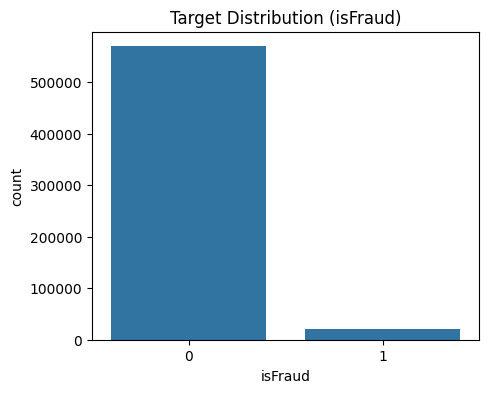

Fraud Rate: 0.03499000914417313


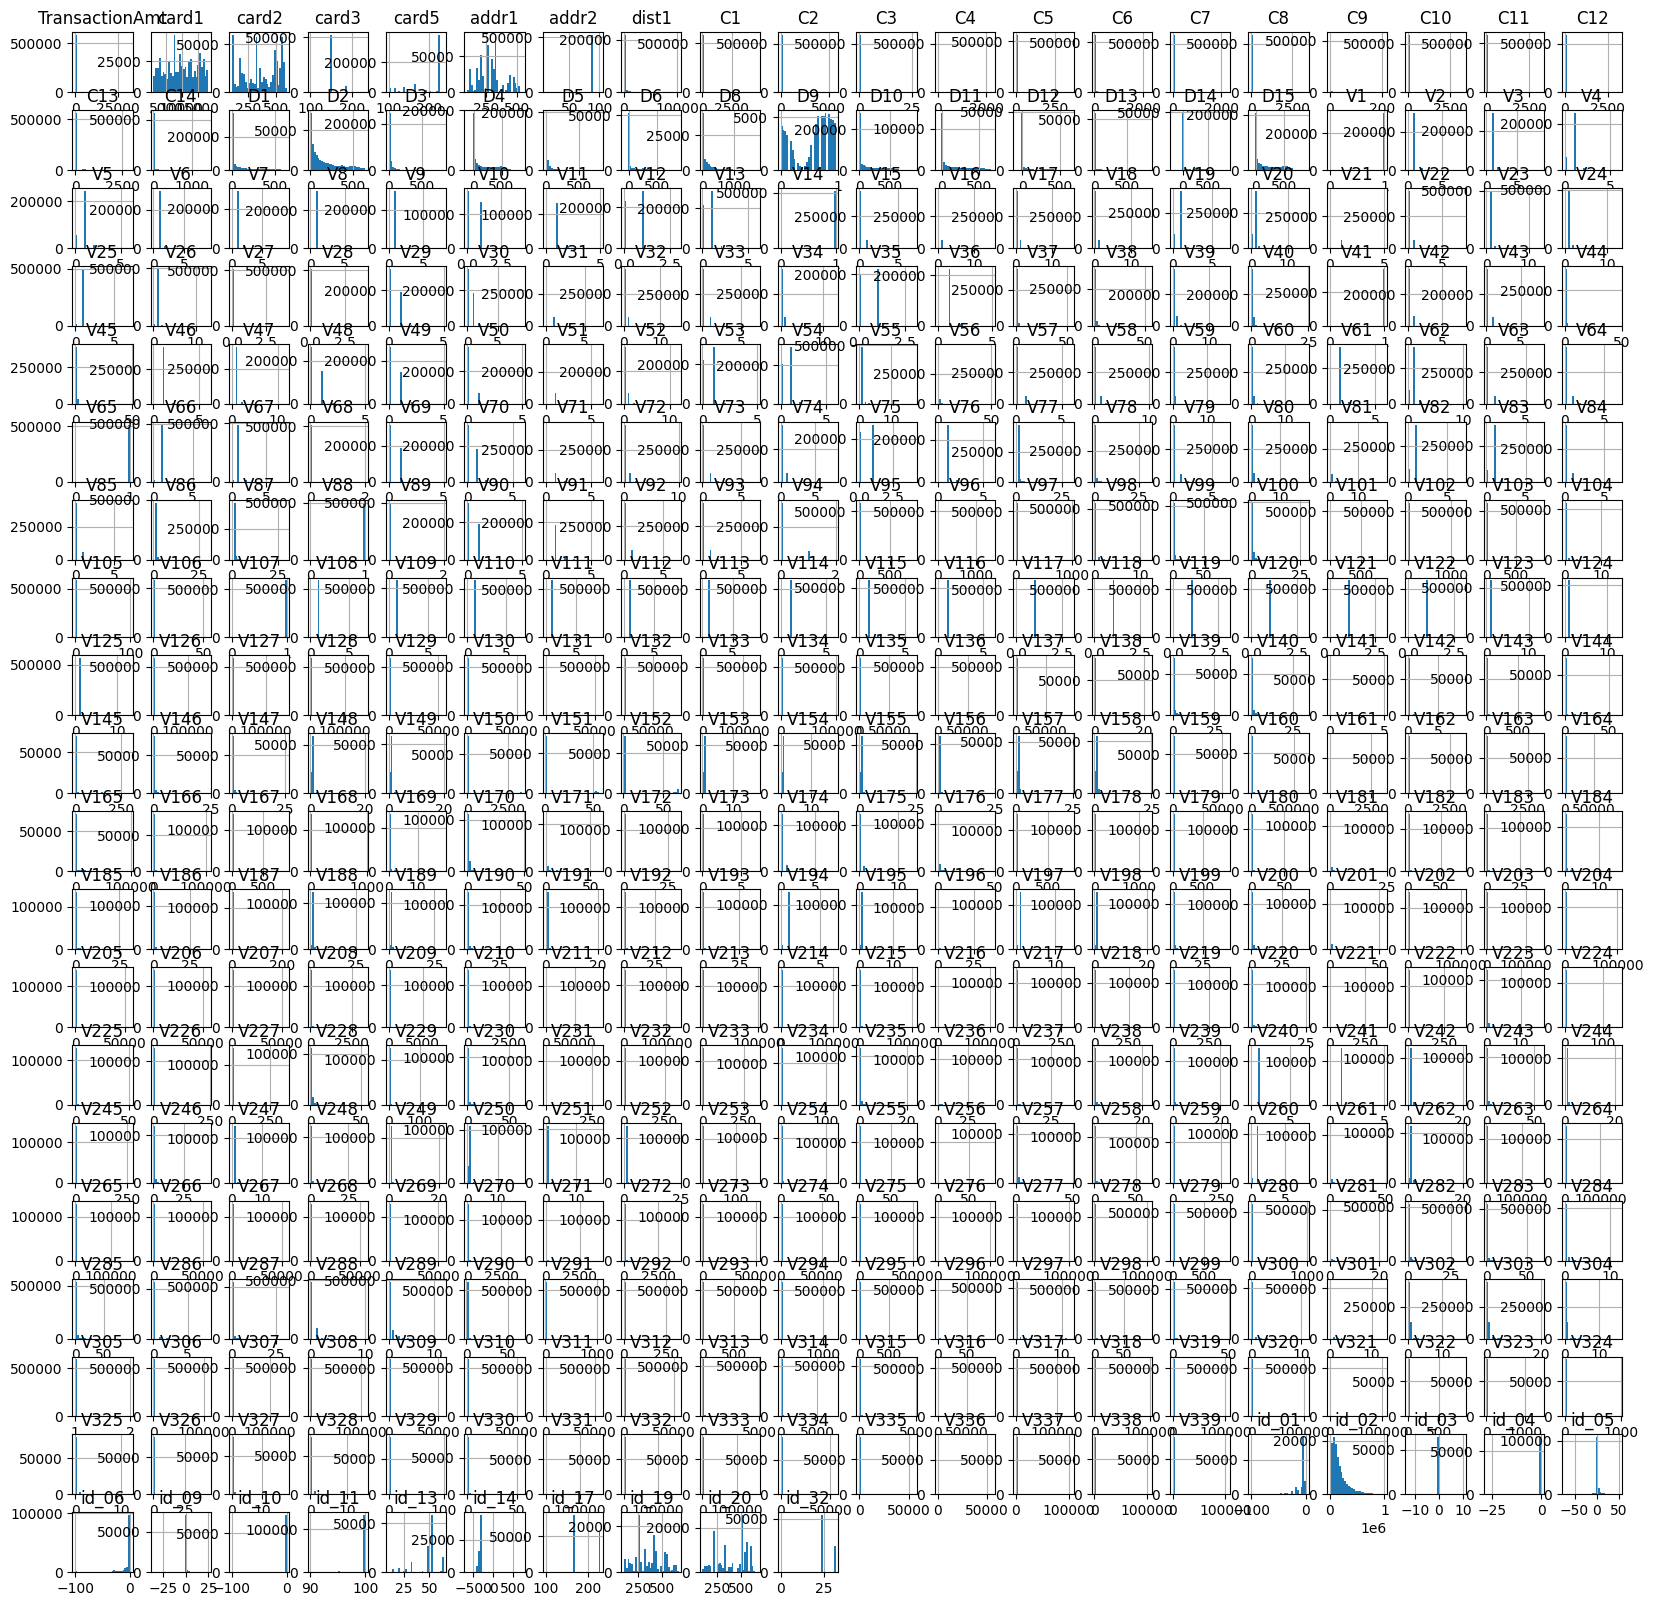

ProductCD unique: 5
card4 unique: 4
card6 unique: 4
P_emaildomain unique: 59
R_emaildomain unique: 60
M1 unique: 2
M2 unique: 2
M3 unique: 2
M4 unique: 3
M5 unique: 2
M6 unique: 2
M7 unique: 2
M8 unique: 2
M9 unique: 2
id_12 unique: 2
id_15 unique: 3
id_16 unique: 2
id_28 unique: 2
id_29 unique: 2
id_30 unique: 75
id_31 unique: 130
id_33 unique: 260
id_34 unique: 4
id_35 unique: 2
id_36 unique: 2
id_37 unique: 2
id_38 unique: 2
DeviceType unique: 2
DeviceInfo unique: 1786


In [4]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Target variable distribution
# sns.countplot(x="isFraud", data=transactions)
# plt.title("Risk Flag Distribution")
# plt.show()

# # Numeric feature distribution
# numeric_cols = [c for c in users_clean.columns if users_clean[c].dtype in ['int64','float64']]
# users_clean[numeric_cols].hist(figsize=(15,10))
# plt.show()

# # Categorical cardinality
# categorical_cols = [c for c in users_clean.columns if users_clean[c].dtype == 'object']
# for col in categorical_cols[:10]:
#     print(col, users_clean[col].nunique())



# Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x=df[TARGET])
plt.title("Target Distribution (isFraud)")
plt.show()

fraud_rate = df[TARGET].mean()
print("Fraud Rate:", fraud_rate)

# Numeric feature distributions
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove(TARGET)

df[numeric_cols].hist(figsize=(20,20), bins=30)
plt.show()

# Categorical cardinality
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    print(col, "unique:", df[col].nunique())

# ⚙️ Task Block 4 – Feature Engineering

In [5]:
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

# # Derived features
# users_clean['device_risk'] = users_clean['DeviceInfo'].apply(lambda x: 1 if pd.notnull(x) and "Build" in str(x) else 0)
# users_clean['id_found_count'] = users_clean[[c for c in users_clean.columns if "id_" in c]].apply(lambda row: sum(row.astype(str).str.contains("Found")), axis=1)
# users_clean['resolution_ratio'] = users_clean['DeviceInfo'].apply(lambda x: None if pd.isnull(x) else 1) # placeholder, parse resolution if available


# Derived features
df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"])
df["card1_bin"] = pd.cut(df["card1"], bins=5, labels=False)
df["addr_match"] = (df["addr1"] == df["addr2"]).astype(int)

# Update feature lists
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove(TARGET)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# ============================================================
# FIXED PREPROCESSOR (WITH IMPUTERS)
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)





# 🤖 Task Block 5 – Model Building

In [6]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, roc_auc_score

# # Merge datasets
# df = transactions.merge(users_clean, on="TransactionID", how="inner")

# X = df.drop(columns=["isFraud"])
# y = df["isFraud"]

# # Identify column types
# numeric_features = X.select_dtypes(include=['int64','float64']).columns
# categorical_features = X.select_dtypes(include=['object']).columns

# # Preprocessing: impute + scale numeric, impute + one-hot encode categorical
# numeric_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])

# categorical_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("encoder", OneHotEncoder(handle_unknown="ignore"))
# ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", numeric_transformer, numeric_features),
#         ("cat", categorical_transformer, categorical_features)
#     ])

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42)

# # Logistic Regression pipeline
# log_reg = Pipeline(steps=[
#     ("preprocessor", preprocessor),
#     ("classifier", LogisticRegression(max_iter=500))
# ])

# log_reg.fit(X_train, y_train)
# y_pred = log_reg.predict(X_test)
# print("Logistic Regression:\n", classification_report(y_test, y_pred))
# print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:,1]))

# # Random Forest pipeline
# rf = Pipeline(steps=[
#     ("preprocessor", preprocessor),
#     ("classifier", RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
# ])

# rf.fit(X_train, y_train)
# y_pred_rf = rf.predict(X_test)
# print("Random Forest:\n", classification_report(y_test, y_pred_rf))
# print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))


X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Baseline model – Logistic Regression
baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=500))
])

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:,1]

print("=== Baseline Model (Logistic Regression) ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Advanced Model 1 – Random Forest
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, max_depth=12))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

# Advanced Model 2 – XGBoost
xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print("=== XGBoost ===")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

=== Baseline Model (Logistic Regression) ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    142469
           1       0.83      0.30      0.44      5166

    accuracy                           0.97    147635
   macro avg       0.90      0.65      0.71    147635
weighted avg       0.97      0.97      0.97    147635

ROC-AUC: 0.8723619825744052
=== Random Forest ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99    142469
           1       0.92      0.25      0.39      5166

    accuracy                           0.97    147635
   macro avg       0.95      0.62      0.69    147635
weighted avg       0.97      0.97      0.97    147635

ROC-AUC: 0.8700094049842364
=== XGBoost ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    142469
           1       0.92      0.48      0.64      5166

    accuracy                           0.98

# 📈 Task Block 6 – Model Evaluation


In [8]:
# # Extract trained RandomForest model
# rf_model = rf.named_steps["classifier"]

# # Transform X_test using the preprocessor
# X_test_transformed = rf.named_steps["preprocessor"].transform(X_test)


# # # Get encoded categorical feature names
# # ohe = rf.named_steps["preprocessor"].named_transformers_["cat"]["encoder"]
# # cat_feature_names = ohe.get_feature_names_out(categorical_features)
# pre = rf.named_steps["preprocessor"]

# # Numeric feature names
# num_feature_names = numeric_features

# # Combined feature names
# all_feature_names = pre.get_feature_names_out()

# import shap

# explainer = shap.TreeExplainer(rf_model)
# shap_values = explainer.shap_values(X_test_transformed)

# shap.summary_plot(shap_values[1], X_test_transformed, feature_names=all_feature_names)

models = {
    "Logistic Regression": roc_auc_score(y_test, y_prob),
    "Random Forest": roc_auc_score(y_test, rf_prob),
    "XGBoost": roc_auc_score(y_test, xgb_prob)
}

print("\nModel Comparison (ROC-AUC):")
print(models)

best_model = xgb_model  # choose best



Model Comparison (ROC-AUC):
{'Logistic Regression': 0.8723619825744052, 'Random Forest': 0.8702888396825667, 'XGBoost': 0.9431205832860348}


# 💾 Task Block 7 – Model Persistence

In [9]:
joblib.dump(best_model, "final_model.pkl")
print("Model saved as final_model.pkl")

# Reload and test
loaded_model = joblib.load("final_model.pkl")
test_pred = loaded_model.predict(X_test)
print("Reloaded model test accuracy:", (test_pred == y_test).mean())

Model saved as final_model.pkl
Reloaded model test accuracy: 0.9805466183493075


# 📤 Task Block 8 – Output & Handoff

In [11]:
# Generate prediction output
df_output = pd.DataFrame({
    "prediction": loaded_model.predict(X),
    "risk_score": loaded_model.predict_proba(X)[:,1]
})

df_output.to_csv("risk_scores.csv", index=False)
print("risk_scores.csv generated successfully")

# Summary
print("""
PHASE 1 COMPLETED:
- Model trained and validated
- Preprocessing pipeline saved
- Predictions generated
- Explainability ready (SHAP can be added)
""")

MemoryError: Unable to allocate 1.65 GiB for an array with shape (374, 590540) and data type float64